# Notebook 06 — Delta-Embeddings Prot-T5 (Zero-Shot)

Computes **delta-embeddings** for Prot-T5 (`prot_t5_xl_uniref50`) and evaluates them as a zero-shot pathogenicity predictor, mirroring notebook 05 (ESM-2).

**Key architectural difference from ESM-2:** Prot-T5 is an **encoder-decoder** model. The log-ratio (notebook 03) used the **decoder** with `<extra_id_0>` masking to obtain masked marginal probabilities. The delta-embedding instead uses the **encoder**, with the mutant residue present in the input sequence (no masking) — analogous to how ESM-2 was used in notebook 05.

**Strategy:**
1. Build wt and mutant sequences (mutant residue substituted at `pos_protein`)
2. Apply a 512-residue centred window (per PROJECT_REFERENCE — practical architecture limit for Prot-T5)
3. Tokenize using `to_prott5_sequence` (space-separated, rare residues mapped to 'X')
4. Run both through the **T5 encoder**, extract hidden state at the mutated position from **layer 24** (last encoder layer)
5. $\Delta\varepsilon = \varepsilon_{mut} - \varepsilon_{wt}$
6. Zero-shot score = $\|\Delta\varepsilon\|_2$

**Methodological note for the paper:** this delta-embedding extraction strategy for Prot-T5 (encoder, unmasked) is **not symmetric** with the log-ratio strategy (decoder, masked) used in notebook 03. This is the same asymmetry already declared for ESM-2 vs Prot-T5 log-ratio, but now also applies *within* Prot-T5 itself, across its two representation types. This should be stated explicitly in Methods.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon
from transformers import T5Tokenizer, T5EncoderModel
from tqdm.auto import tqdm

from bio_var_pred.embeddings.assess import to_prott5_sequence
from bio_var_pred.embeddings.checkpoint import restore_np_checkpoint
from bio_var_pred.embeddings.setup import get_device
from bio_var_pred.metrics.compute import compute_delta_norm
from bio_var_pred.metrics.evaluate import evaluate_gene, assign_stratum
from bio_var_pred.utils.paths import PROCESSED_DATA_DIR

%load_ext dotenv
%dotenv

In [2]:
DEVICE = get_device()

PyTorch version: 2.11.0
MPS available
Using device: mps


## 1. Load dataset

In [3]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "variants_with_scores.parquet")

print(f"Variants: {len(df):,}")
print(f"Genes: {df['gene'].nunique():,}")
print(f"Columns: {df.columns.tolist()}")

assert "esm2_delta_norm" in df.columns, \
    "esm2_delta_norm missing — run notebook 05 first"
df.head()

Variants: 54,821
Genes: 2,252
Columns: ['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio', 'prott5_log_ratio', 'esm2_delta_norm', 'prott5_delta_norm']


,id,chrom,pos_genomic,ref,alt,gene,transcript_id,pos_protein,aa_wt,aa_mut,label,protein_seq,af,ac,an,log_af,esm2_log_ratio,prott5_log_ratio,esm2_delta_norm,prott5_delta_norm
0,387476,1,1020183,G,C,AGRN,ENST00000379370,4,R,P,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.000994,1176.0,1182524.0,-3.002398,-3.081203,1.521034,4.189582,2.018191
1,263204,1,1041218,C,T,AGRN,ENST00000379370,258,T,I,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001124,1484.0,1319880.0,-2.949098,-6.396329,-2.463169,3.355133,0.904710
2,128291,1,1041583,A,G,AGRN,ENST00000379370,353,Q,R,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001738,2529.0,1454750.0,-2.759838,-1.381803,1.796480,3.731554,0.994419
3,263158,1,1041648,G,T,AGRN,ENST00000379370,375,A,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.006713,9794.0,1458968.0,-2.173085,-5.311023,-0.940014,3.296486,0.753585
4,263163,1,1043382,G,A,AGRN,ENST00000379370,510,G,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.010539,15353.0,1456748.0,-1.977192,-5.103392,15.489303,4.023306,1.071313


In [4]:
# Sanity checks (same as notebook 05)
assert df["protein_seq"].str.contains("X").sum() == 0, \
    "Sequences with 'X' should have been filtered in notebook 02/03"

assert df["label"].isin([0, 1]).all(), "Labels must be binary"

mismatch = df.apply(
    lambda r: r["protein_seq"][r["pos_protein"] - 1] != r["aa_wt"], axis=1
).sum()
assert mismatch == 0, f"{mismatch} wt residue mismatches found"

print("All sanity checks passed.")

All sanity checks passed.


## 2. Load Prot-T5 encoder

Using `T5EncoderModel` (encoder only) since the delta-embedding strategy does not require the decoder.

In [5]:
MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
HF_TOKEN = os.environ.get("HF_TOKEN")

LAYER = 24  # last encoder layer
WINDOW = 512  # practical limit for Prot-T5

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, do_lower_case=False, token=HF_TOKEN)
model = T5EncoderModel.from_pretrained(MODEL_NAME, output_hidden_states=True, token=HF_TOKEN)
model.eval()
model.to(DEVICE)

# Full precision, per PROJECT_REFERENCE (no fp16/bf16 cast)
print(f"Model loaded: {MODEL_NAME}")
print(f"Extracting encoder hidden states from layer {LAYER}")
print(f"Param dtype: {next(model.parameters()).dtype}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] T5EncoderModel LOAD REPORT from: Rostlab/prot_t5_xl_uniref50
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: Rostlab/prot_t5_xl_uniref50
Extracting encoder hidden states from layer 24
Param dtype: torch.float32


## 3. Delta-embedding extraction

**IMPORTANT — verify before running at scale:**

In [6]:
# Alignment sanity check on a small sample
sample = df.sample(5, random_state=42)

for _, row in sample.iterrows():
    spaced = to_prott5_sequence(row["protein_seq"][:50])  # just inspect the prefix
    print(f"id={row['id']}  pos_protein={row['pos_protein']}  aa_wt={row['aa_wt']}")
    print(f"  spaced (first 50 res): {spaced}")
    tokens = tokenizer.tokenize(to_prott5_sequence(row["protein_seq"]))
    pos = row["pos_protein"]
    print(f"  token at index pos-1 ({pos - 1}): {tokens[pos - 1] if pos - 1 < len(tokens) else 'OUT OF RANGE'}")
    print(f"  expected wt residue: {row['aa_wt']}")
    print()

id=549081  pos_protein=811  aa_wt=C
  spaced (first 50 res): M R R G R L L E I A L G F T V L L A S Y T S H G A D A N L E A G N V K E T R A S R A K R R G G G G H
  token at index pos-1 (810): ▁C
  expected wt residue: C

id=4087094  pos_protein=69  aa_wt=A
  spaced (first 50 res): M Q L R N P E L H L G C A L A L R F L A L V S W D I P G A R A L D N G L A R T P T M G W L H W E R F
  token at index pos-1 (68): ▁A
  expected wt residue: A

id=95075  pos_protein=31  aa_wt=T
  spaced (first 50 res): M L V P L A K L S C L A Y Q C F H A L K I K K N Y L P L C A T R W S S T S T V P R I T T H Y T I Y P
  token at index pos-1 (30): ▁T
  expected wt residue: T

id=321000  pos_protein=2974  aa_wt=M
  spaced (first 50 res): M P G E R P R G A P P P T M T G D L Q P R Q V A S S P G H P S Q P P L E D N T P A T R T T K G A R E
  token at index pos-1 (2973): ▁M
  expected wt residue: M

id=456836  pos_protein=130  aa_wt=G
  spaced (first 50 res): M L S F V D T R T L L L L A V T L C L A T C Q S L Q E E T V R

### 3.2 Inference loop with checkpointing

In [7]:
CHECKPOINT_PATH = PROCESSED_DATA_DIR / "delta_norms_prott5_checkpoint.npy"
CHECKPOINT_INTERVAL = 500

n = len(df)

# Load checkpoint if it exists
delta_norms, start_idx = restore_np_checkpoint(CHECKPOINT_PATH, n)

for i, (_, row) in enumerate(
    tqdm(df.iloc[start_idx:].iterrows(), total=n - start_idx, desc="Prot-T5 delta-embeddings")
):
    try:
        norm = compute_delta_norm(row, model, tokenizer, DEVICE, layer=LAYER)
    except Exception as e:
        print(f"\nError at index {start_idx + i} (id={row['id']}): {e}")
        norm = np.nan

    delta_norms.append(norm)

    if (len(delta_norms)) % CHECKPOINT_INTERVAL == 0:
        np.save(CHECKPOINT_PATH, np.array(delta_norms))

np.save(CHECKPOINT_PATH, np.array(delta_norms))
print(f"\nDone. {sum(np.isnan(delta_norms))} NaNs out of {len(delta_norms)} variants.")

Resuming from checkpoint: 54821/54821 variants processed


Prot-T5 delta-embeddings: 0it [00:00, ?it/s]


Done. 0 NaNs out of 54821 variants.


### 3.3 Attach scores to dataframe

In [8]:
assert len(delta_norms) == len(df), \
    f"Length mismatch: {len(delta_norms)} scores vs {len(df)} variants"

df["prott5_delta_norm"] = np.array(delta_norms, dtype=np.float32)

print(f"prott5_delta_norm — non-null: {df['prott5_delta_norm'].notna().sum():,}")
df["prott5_delta_norm"].describe()

prott5_delta_norm — non-null: 54,821


count    54821.000000
mean         1.299783
std          0.699096
min          0.015035
25%          0.867321
50%          1.138988
75%          1.511679
max          8.430442
Name: prott5_delta_norm, dtype: float64

In [10]:
out_path = PROCESSED_DATA_DIR / "variants_with_scores.parquet"
df.to_parquet(out_path)
print(f"Saved to {out_path}")
print(f"Columns: {df.columns.tolist()}")

Saved to /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/variants_with_scores.parquet
Columns: ['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio', 'prott5_log_ratio', 'esm2_delta_norm', 'prott5_delta_norm']


## 4. Zero-shot evaluation — per-gene ROC-AUC and PR-AUC

In [9]:
records = []
for gene, grp in df.groupby("gene"):
    result = evaluate_gene(grp, "prott5_delta_norm")
    if result is not None:
        result["gene"] = gene
        records.append(result)

delta_metrics_t5 = pd.DataFrame(records)
delta_metrics_t5["prevalence"] = delta_metrics_t5["n_pathogenic"] / delta_metrics_t5["n_variants"]

delta_metrics_t5["stratum"] = delta_metrics_t5["n_variants"].apply(assign_stratum)

print(f"Genes evaluated: {len(delta_metrics_t5):,}")
print(f"Variants covered: {delta_metrics_t5['n_variants'].sum():,}")
delta_metrics_t5.head()

Genes evaluated: 2,252
Variants covered: 54,821


,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,gene,prevalence,stratum
0,0.500000,0.333333,5,1,4,A4GALT,0.200000,5–10
1,0.177778,0.510287,14,9,5,AAAS,0.642857,11–50
2,0.714286,0.711447,15,7,8,AARS1,0.466667,11–50
3,0.625000,0.566376,22,10,12,AARS2,0.454545,11–50
4,0.500000,0.450000,6,2,4,AASS,0.333333,5–10


## 5. Global metrics

In [11]:
roc_med  = delta_metrics_t5["roc_auc"].median()
roc_iqr  = delta_metrics_t5["roc_auc"].quantile([0.25, 0.75]).array
prauc_med = delta_metrics_t5["pr_auc"].median()
prauc_iqr = delta_metrics_t5["pr_auc"].quantile([0.25, 0.75]).array

print("=== Prot-T5 Delta-Norm (Zero-Shot) ===")
print(f"ROC-AUC  median: {roc_med:.3f}  IQR: [{roc_iqr[0]:.3f}, {roc_iqr[1]:.3f}]")
print(f"PR-AUC   median: {prauc_med:.3f}  IQR: [{prauc_iqr[0]:.3f}, {prauc_iqr[1]:.3f}]")

=== Prot-T5 Delta-Norm (Zero-Shot) ===
ROC-AUC  median: 0.635  IQR: [0.429, 0.812]
PR-AUC   median: 0.692  IQR: [0.391, 0.910]


## 6. Comparison with Prot-T5 log-ratio and ESM-2 delta-norm

In [12]:
# 6.1 vs Prot-T5 log-ratio (per-gene, computed directly here since notebook 04
# only evaluated ESM-2; recompute for prott5_log_ratio for a fair comparison)
records_logr_t5 = []
for gene, grp in df.groupby("gene"):
    result = evaluate_gene(grp, "prott5_log_ratio")
    if result is not None:
        result["gene"] = gene
        records_logr_t5.append(result)

logr_metrics_t5 = pd.DataFrame(records_logr_t5)[["gene", "roc_auc", "pr_auc"]].rename(
    columns={"roc_auc": "roc_auc_logr_t5", "pr_auc": "pr_auc_logr_t5"}
)

comparison_t5 = delta_metrics_t5.merge(logr_metrics_t5, on="gene", how="inner")

stat, p = wilcoxon(comparison_t5["roc_auc"], comparison_t5["roc_auc_logr_t5"])
print("=== Wilcoxon: Prot-T5 delta-norm vs Prot-T5 log-ratio (ROC-AUC) ===")
print(f"Statistic: {stat:.2f}   p-value: {p:.3e}")
print(f"Genes compared: {len(comparison_t5):,}")

=== Wilcoxon: Prot-T5 delta-norm vs Prot-T5 log-ratio (ROC-AUC) ===
Statistic: 689132.00   p-value: 8.230e-55
Genes compared: 2,252


In [19]:
logr_metrics_t5.describe()

,roc_auc_logr_t5,pr_auc_logr_t5
count,2252.000000,2252.000000
mean,0.483722,0.565234
std,0.243495,0.290360
min,0.000000,0.006667
25%,0.333333,0.325000
50%,0.490290,0.578948
75%,0.650000,0.833333
max,1.000000,1.000000


In [13]:
# 6.2 vs ESM-2 delta-norm (notebook 05)
esm2_delta_metrics = pd.read_parquet(
    PROCESSED_DATA_DIR / "delta_gene_metrics_esm2.parquet"
)[["gene", "roc_auc", "pr_auc"]].rename(
    columns={"roc_auc": "roc_auc_esm2_delta", "pr_auc": "pr_auc_esm2_delta"}
)

cross_model = delta_metrics_t5.merge(esm2_delta_metrics, on="gene", how="inner")

stat2, p2 = wilcoxon(cross_model["roc_auc_esm2_delta"], cross_model["roc_auc"])
print("=== Wilcoxon: ESM-2 delta-norm vs Prot-T5 delta-norm (ROC-AUC) ===")
print(f"Statistic: {stat2:.2f}   p-value: {p2:.3e}")
print(f"Genes compared: {len(cross_model):,}")

=== Wilcoxon: ESM-2 delta-norm vs Prot-T5 delta-norm (ROC-AUC) ===
Statistic: 473994.00   p-value: 6.796e-104
Genes compared: 2,252


## 7. Correlations

In [14]:
rho_size, p_size = stats.spearmanr(
    delta_metrics_t5["n_variants"], delta_metrics_t5["roc_auc"]
)
print(f"ROC-AUC vs gene size:   Spearman ρ = {rho_size:.3f}  p = {p_size:.2e}")

rho_prev, p_prev = stats.spearmanr(
    delta_metrics_t5["prevalence"], delta_metrics_t5["pr_auc"]
)
print(f"PR-AUC  vs prevalence:  Spearman ρ = {rho_prev:.3f}  p = {p_prev:.2e}")

rho_roc_prev, p_roc_prev = stats.spearmanr(
    delta_metrics_t5["prevalence"], delta_metrics_t5["roc_auc"]
)
print(f"ROC-AUC vs prevalence:  Spearman ρ = {rho_roc_prev:.3f}  p = {p_roc_prev:.2e}")

ROC-AUC vs gene size:   Spearman ρ = -0.058  p = 6.26e-03
PR-AUC  vs prevalence:  Spearman ρ = 0.664  p = 1.10e-286
ROC-AUC vs prevalence:  Spearman ρ = -0.001  p = 9.49e-01


## 8. Figures

In [15]:
FIGURE_DIR = PROCESSED_DATA_DIR
STRAT_ORDER = ["5–10", "11–50", ">50"]
STRAT_COLORS = ["#fc8d62", "#e34a33", "#990000"]

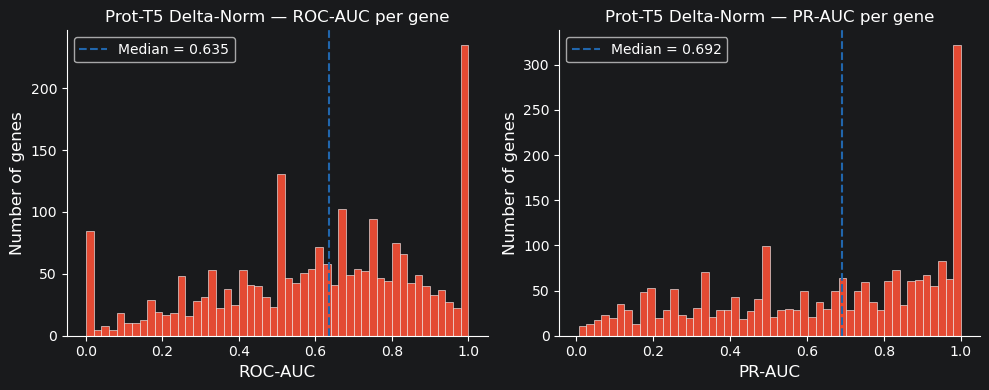

In [16]:
# Fig 1: ROC-AUC / PR-AUC distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ["roc_auc", "pr_auc"], ["ROC-AUC", "PR-AUC"]):
    ax.hist(delta_metrics_t5[col].dropna(), bins=50, color="#e34a33", edgecolor="white", linewidth=0.4)
    med = delta_metrics_t5[col].median()
    ax.axvline(med, color="#2166ac", linewidth=1.5, linestyle="--", label=f"Median = {med:.3f}")
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Number of genes", fontsize=12)
    ax.set_title(f"Prot-T5 Delta-Norm — {label} per gene", fontsize=12)
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_t5_auc_distributions.pdf", dpi=150)
plt.show()

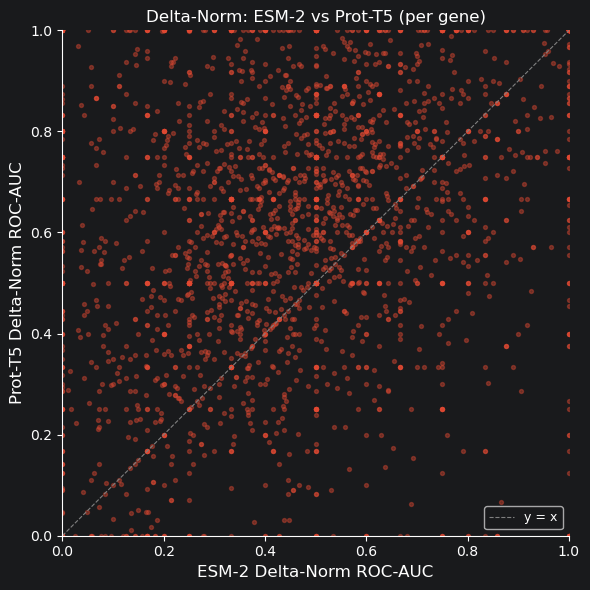

In [17]:
# Fig 2: Scatter — ESM-2 delta-norm vs Prot-T5 delta-norm (per gene ROC-AUC)
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    cross_model["roc_auc_esm2_delta"],
    cross_model["roc_auc"],
    alpha=0.4,
    s=8,
    color="#e34a33",
    rasterized=True,
)
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=0.8, label="y = x")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("ESM-2 Delta-Norm ROC-AUC", fontsize=12)
ax.set_ylabel("Prot-T5 Delta-Norm ROC-AUC", fontsize=12)
ax.set_title("Delta-Norm: ESM-2 vs Prot-T5 (per gene)", fontsize=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_delta_esm2_vs_prott5.pdf", dpi=150)
plt.show()

## 9. Save per-gene metrics

In [18]:
metrics_path = PROCESSED_DATA_DIR / "delta_gene_metrics_prott5.parquet"
delta_metrics_t5.to_parquet(metrics_path, index=False)
print(f"Saved {metrics_path}")
delta_metrics_t5.describe()

Saved /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/delta_gene_metrics_prott5.parquet


,roc_auc,pr_auc,n_variants,n_pathogenic,n_benign,prevalence
count,2252.000000,2252.000000,2252.00000,2252.000000,2252.000000,2252.000000
mean,0.607034,0.636068,24.34325,13.154973,11.188277,0.469848
std,0.270147,0.294143,43.31664,34.755418,23.844530,0.288987
min,0.000000,0.007353,5.00000,1.000000,1.000000,0.004587
25%,0.428571,0.390670,7.00000,2.000000,3.000000,0.200000
50%,0.634554,0.691823,12.00000,4.000000,6.000000,0.428571
75%,0.812500,0.910031,23.00000,11.000000,11.000000,0.750000
max,1.000000,1.000000,859.00000,836.000000,675.000000,0.988539
